## Statistics for AI: Probability & Model Confidence
## Complete Course Lecture & Interactive Guide


### What You Will Learn
1. ✅ Normal Distribution (Bell Curve)
2. ✅ Z-Scores & Standardization
3. ✅ Frequentist Probability Theory
4. ✅ Bayesian Probability Theory
5. ✅ Building a Confidence Score System
6. ✅ Model Calibration & Validation

---

# SECTION A: SETUP & IMPORTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# Professional visualization settings
sns.set_theme(style='whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ All libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ All libraries imported successfully
NumPy version: 2.4.4
Pandas version: 3.0.2


---

# SECTION B: TOPIC 1 - NORMAL DISTRIBUTION

## What is Normal Distribution?

The **Normal Distribution** (also called Gaussian or Bell Curve) is the most important probability distribution in statistics and machine learning.

### Why Does It Matter?
- Appears naturally in countless phenomena (height, test scores, measurement errors)
- Many ML algorithms assume data is normally distributed
- Foundation for hypothesis testing and confidence intervals
- Helps identify outliers

### Mathematical Definition
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

Where:
- **μ (mu)** = Mean (center of distribution)
- **σ (sigma)** = Standard Deviation (spread/width)
- **π** = 3.14159...
- **e** = 2.71828... (Euler's number)

### Key Properties
- **Symmetric**: Left half mirrors right half
- **Unimodal**: One peak (most likely value is the mean)
- **Defined by 2 parameters**: μ and σ
- **Total area under curve**: Always equals 1 (probability)

## The 68-95-99.7 Rule (Empirical Rule)

This is THE most important rule in statistics!

| Range | Percentage |
|-------|------------|
| ±1σ (within 1 std dev) | **68.27%** |
| ±2σ (within 2 std dev) | **95.45%** |
| ±3σ (within 3 std dev) | **99.73%** |

### What This Means
- If average height is 170cm with σ=5cm:
  - 68% of people: 165-175cm
  - 95% of people: 160-180cm
  - 99.7% of people: 155-185cm
  - 0.3% people: Outside 155-185cm (very unusual!)

In [2]:
# Generate data from normal distribution
print("\n" + "="*70)
print("LECTURE 1.1: GENERATING & ANALYZING NORMAL DISTRIBUTION")
print("="*70)

mu = 100  # Mean
sigma = 15  # Standard deviation
n_samples = 10000  # Generate 10,000 samples

# Generate data
data = np.random.normal(mu, sigma, n_samples)

# Calculate statistics
print(f"\nGenerated {n_samples} samples from Normal(μ={mu}, σ={sigma})")
print(f"\nSample Statistics:")
print(f"  Mean: {data.mean():.2f} (expected: {mu})")
print(f"  Std Dev: {data.std():.2f} (expected: {sigma})")
print(f"  Min: {data.min():.2f}")
print(f"  Max: {data.max():.2f}")

# Verify 68-95-99.7 rule
within_1sigma = np.sum((data >= mu - sigma) & (data <= mu + sigma)) / n_samples * 100
within_2sigma = np.sum((data >= mu - 2*sigma) & (data <= mu + 2*sigma)) / n_samples * 100
within_3sigma = np.sum((data >= mu - 3*sigma) & (data <= mu + 3*sigma)) / n_samples * 100

print(f"\n68-95-99.7 Rule Verification (Empirical):")
print(f"  ±1σ: {within_1sigma:.2f}% (theory: 68.27%)")
print(f"  ±2σ: {within_2sigma:.2f}% (theory: 95.45%)")
print(f"  ±3σ: {within_3sigma:.2f}% (theory: 99.73%)")
print(f"\n✓ Our empirical data matches the theoretical rule!")


LECTURE 1.1: GENERATING & ANALYZING NORMAL DISTRIBUTION

Generated 10000 samples from Normal(μ=100, σ=15)

Sample Statistics:
  Mean: 99.97 (expected: 100)
  Std Dev: 15.05 (expected: 15)
  Min: 41.16
  Max: 158.89

68-95-99.7 Rule Verification (Empirical):
  ±1σ: 68.20% (theory: 68.27%)
  ±2σ: 95.33% (theory: 95.45%)
  ±3σ: 99.72% (theory: 99.73%)

✓ Our empirical data matches the theoretical rule!


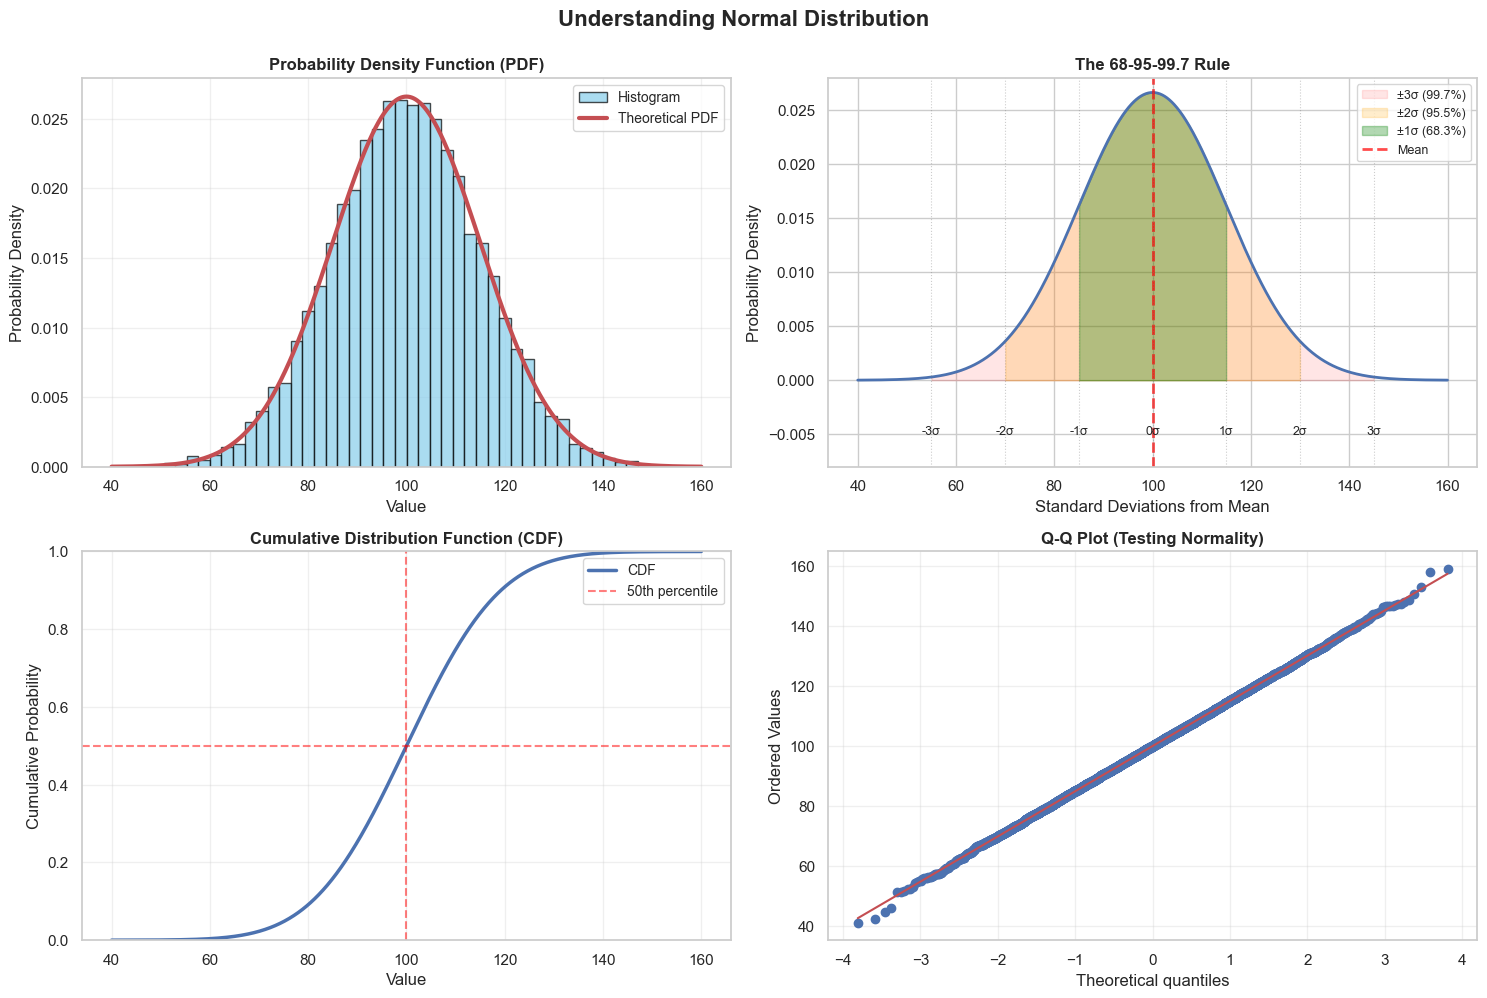


✓ Visualization saved!


In [3]:
# Visualization 1: Normal Distribution Components
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Understanding Normal Distribution', fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Histogram + PDF
ax = axes[0, 0]
ax.hist(data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Histogram')
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=3, label='Theoretical PDF')
ax.set_title('Probability Density Function (PDF)', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: 68-95-99.7 Rule
ax = axes[0, 1]
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma)

# Fill colored regions
x1 = x[(x >= mu - 1*sigma) & (x <= mu + 1*sigma)]
x2 = x[(x >= mu - 2*sigma) & (x <= mu + 2*sigma)]
x3 = x[(x >= mu - 3*sigma) & (x <= mu + 3*sigma)]

ax.fill_between(x3, stats.norm.pdf(x3, mu, sigma), alpha=0.1, color='red', label='±3σ (99.7%)')
ax.fill_between(x2, stats.norm.pdf(x2, mu, sigma), alpha=0.2, color='orange', label='±2σ (95.5%)')
ax.fill_between(x1, stats.norm.pdf(x1, mu, sigma), alpha=0.3, color='green', label='±1σ (68.3%)')

ax.plot(x, y, 'b-', linewidth=2)
ax.axvline(mu, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Mean')

# Add sigma markers
for i in range(-3, 4):
    ax.axvline(mu + i*sigma, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.text(mu + i*sigma, -0.005, f'{i}σ', ha='center', fontsize=9)

ax.set_title('The 68-95-99.7 Rule', fontweight='bold')
ax.set_xlabel('Standard Deviations from Mean')
ax.set_ylabel('Probability Density')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(bottom=-0.008)

# Plot 3: Cumulative Distribution Function (CDF)
ax = axes[1, 0]
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.cdf(x, mu, sigma)
ax.plot(x, y, 'b-', linewidth=2.5, label='CDF')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50th percentile')
ax.axvline(mu, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Cumulative Distribution Function (CDF)', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Cumulative Probability')
ax.set_ylim([0, 1])
ax.legend(fontsize=10)

# Plot 4: Q-Q Plot (checking normality)
ax = axes[1, 1]
stats.probplot(data, dist='norm', plot=ax)
ax.set_title('Q-Q Plot (Testing Normality)', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/salmansakib/Documents/Projects/interview-Prep-Case-Study/Job Ready AI Bootcamp/week 3/Class 2 Project/lecture_1_normal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved!")

---

# SECTION C: TOPIC 2 - Z-SCORES & STANDARDIZATION

## What is a Z-Score?

A **Z-Score** tells you how many standard deviations a value is from the mean.

### Formula
$$Z = \frac{X - \mu}{\sigma}$$

Where:
- **X** = Your value
- **μ** = Mean of the distribution
- **σ** = Standard deviation
- **Z** = How many std devs away from mean

### Interpretation
| Z-Score | Meaning | Percentile |
|---------|---------|------------|
| Z = 0 | Value equals mean | 50th |
| Z = 1 | 1 std dev above mean | 84th |
| Z = 2 | 2 std devs above mean | 97.7th |
| Z = 3 | 3 std devs above mean | 99.9th |
| Z = -1 | 1 std dev below mean | 16th |
| Z = -2 | 2 std devs below mean | 2.3rd |

### Why Use Z-Scores?
1. **Standardization**: Convert any data to comparable scale (mean=0, std=1)
2. **Outlier Detection**: Values with |Z| > 3 are very unusual
3. **ML Preprocessing**: Many algorithms work better with standardized data
4. **Comparison**: Compare values from different distributions

### Real-World Example
```
Test Score Distribution:
  Mean = 75, Std Dev = 5
  
Your Score = 85
  Z = (85 - 75) / 5 = 2.0
  
Interpretation: You scored 2 standard deviations above average!
Percentile: 97.7% (better than 97.7% of test takers)
```

In [4]:
print("\n" + "="*70)
print("LECTURE 2: Z-SCORES & STANDARDIZATION")
print("="*70)

# Example: Test scores
test_scores = np.random.normal(loc=75, scale=10, size=1000)
test_scores = np.clip(test_scores, 0, 100)

mean_score = test_scores.mean()
std_score = test_scores.std()

print(f"\nTest Score Distribution:")
print(f"  Mean: {mean_score:.2f}")
print(f"  Std Dev: {std_score:.2f}")

# Calculate Z-scores
z_scores = (test_scores - mean_score) / std_score

print(f"\nZ-Score Statistics:")
print(f"  Mean of Z-scores: {z_scores.mean():.4f} (should be 0)")
print(f"  Std Dev of Z-scores: {z_scores.std():.4f} (should be 1)")

# Example calculations
print(f"\nExample Calculations:")
example_scores = [50, 75, 85, 95]
for score in example_scores:
    z = (score - mean_score) / std_score
    percentile = stats.norm.cdf(z) * 100
    print(f"\n  Score {score}:")
    print(f"    Z-score: {z:.2f}")
    print(f"    Percentile: {percentile:.1f}%")
    if abs(z) > 3:
        print(f"    Status: 🚨 VERY UNUSUAL (outlier)")
    elif abs(z) > 2:
        print(f"    Status: ⚠️  UNUSUAL")
    elif abs(z) > 1:
        print(f"    Status: Normal (but notable)")
    else:
        print(f"    Status: ✓ Common")


LECTURE 2: Z-SCORES & STANDARDIZATION

Test Score Distribution:
  Mean: 74.59
  Std Dev: 9.67

Z-Score Statistics:
  Mean of Z-scores: 0.0000 (should be 0)
  Std Dev of Z-scores: 1.0000 (should be 1)

Example Calculations:

  Score 50:
    Z-score: -2.54
    Percentile: 0.6%
    Status: ⚠️  UNUSUAL

  Score 75:
    Z-score: 0.04
    Percentile: 51.7%
    Status: ✓ Common

  Score 85:
    Z-score: 1.08
    Percentile: 85.9%
    Status: Normal (but notable)

  Score 95:
    Z-score: 2.11
    Percentile: 98.3%
    Status: ⚠️  UNUSUAL


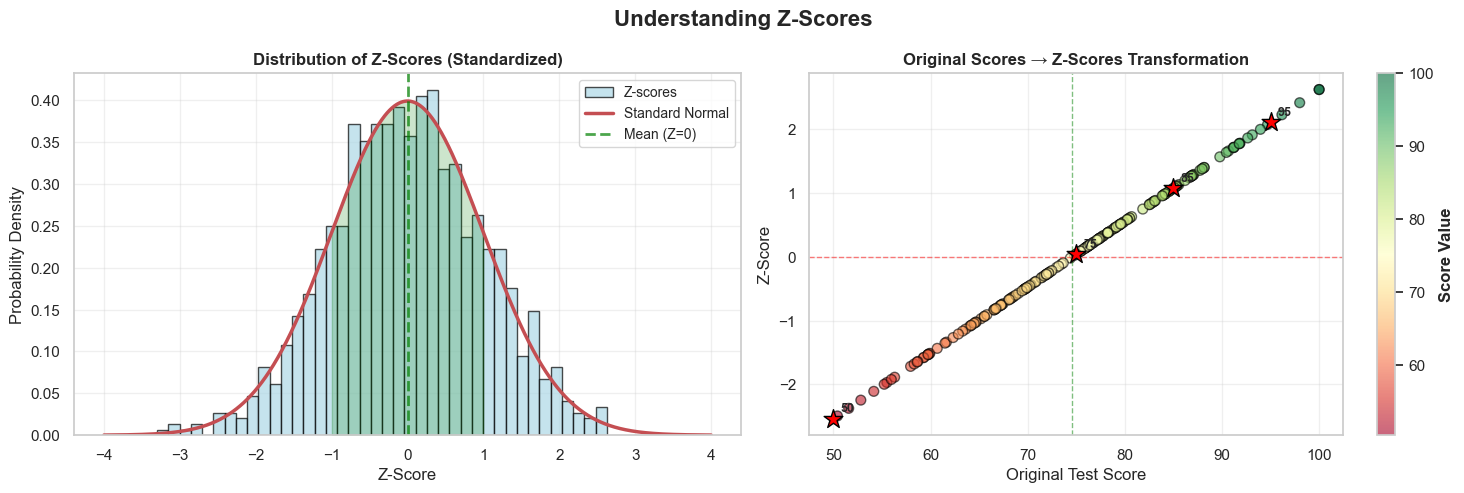


✓ Z-Score visualization saved!


In [5]:
# Visualization 2: Z-Scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Understanding Z-Scores', fontsize=16, fontweight='bold')

# Plot 1: Original vs Z-scores
ax = axes[0]
ax.hist(z_scores, bins=40, density=True, alpha=0.7, color='lightblue', edgecolor='black', label='Z-scores')
x = np.linspace(-4, 4, 1000)
ax.plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2.5, label='Standard Normal')
ax.axvline(0, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Mean (Z=0)')
ax.fill_between(x[(x>=-1) & (x<=1)], stats.norm.pdf(x[(x>=-1) & (x<=1)], 0, 1), alpha=0.2, color='green')
ax.set_title('Distribution of Z-Scores (Standardized)', fontweight='bold')
ax.set_xlabel('Z-Score')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Original scores vs Z-scores
ax = axes[1]
sample_indices = np.random.choice(len(test_scores), 200, replace=False)
scatter = ax.scatter(test_scores[sample_indices], z_scores[sample_indices], 
                     c=test_scores[sample_indices], cmap='RdYlGn', alpha=0.6, s=50, edgecolors='black')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(mean_score, color='green', linestyle='--', linewidth=1, alpha=0.5)

# Mark example scores
for score in example_scores:
    z = (score - mean_score) / std_score
    ax.scatter([score], [z], s=200, marker='*', color='red', edgecolors='black', zorder=5)
    ax.annotate(f'{score}', (score, z), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_title('Original Scores → Z-Scores Transformation', fontweight='bold')
ax.set_xlabel('Original Test Score')
ax.set_ylabel('Z-Score')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Score Value', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/salmansakib/Documents/Projects/interview-Prep-Case-Study/Job Ready AI Bootcamp/week 3/Class 2 Project/lecture_2_z_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Z-Score visualization saved!")

---

# SECTION D: TOPIC 3 - FREQUENTIST PROBABILITY

## What is Frequentist Probability?

**Frequentist Probability** = Long-run frequency of an event

### Core Idea
> "If we repeat an experiment infinitely many times, the probability is the fraction of times the event occurs."

### Formula
$$P(Event) = \lim_{n \to \infty} \frac{\text{# times event occurred}}{\text{# total trials}}$$

### Real Example: Coin Flip
```
Flip a coin 10 times: 4 heads → P(Heads) ≈ 0.4
Flip a coin 100 times: 51 heads → P(Heads) ≈ 0.51
Flip a coin 1,000 times: 499 heads → P(Heads) ≈ 0.499
Flip a coin ∞ times: P(Heads) = 0.5 (theoretical)
```

### Key Concepts

#### 1. Law of Large Numbers
As sample size increases, observed probability converges to true probability.

#### 2. Standard Error
$$SE = \sqrt{\frac{p(1-p)}{n}}$$

How uncertain is our estimate? Smaller SE = better estimate.

#### 3. Confidence Interval (95%)
$$CI = \text{estimate} \pm 1.96 \times SE$$

**Interpretation**: "If we repeated this experiment 100 times, ~95 times the true value would fall in this range."

### Why Frequentist?
✅ Intuitive (based on repetition)  
✅ No prior beliefs needed  
✅ Works well with large samples  
❌ Can't update beliefs easily  
❌ Limited for small samples

In [6]:
print("\n" + "="*70)
print("LECTURE 3: FREQUENTIST PROBABILITY")
print("="*70)

print("\nDemonstration: Coin Flip Convergence")
print("-" * 70)

# Simulate coin flips
n_trials_list = [10, 100, 1000, 10000, 100000]
print(f"\nTrue probability of heads: 0.5")
print(f"\nObserved probability with different sample sizes:")

for n in n_trials_list:
    flips = np.random.binomial(n=1, p=0.5, size=n)
    p_observed = flips.mean()
    error = abs(p_observed - 0.5)
    
    # Standard error
    se = np.sqrt(0.5 * 0.5 / n)
    
    # 95% Confidence interval
    z_95 = 1.96
    ci_lower = p_observed - z_95 * se
    ci_upper = p_observed + z_95 * se
    
    print(f"\n  {n:>6} flips:")
    print(f"    Observed P: {p_observed:.5f}")
    print(f"    Error: {error:.5f}")
    print(f"    Std Error: {se:.5f}")
    print(f"    95% CI: [{ci_lower:.5f}, {ci_upper:.5f}]")
    
    if 0.5 >= ci_lower and 0.5 <= ci_upper:
        print(f"    ✓ True value (0.5) is in CI")
    else:
        print(f"    ✗ True value (0.5) is NOT in CI")

print(f"\n→ As we flip more, confidence interval gets narrower!")
print(f"→ Larger sample = more certain about true probability")


LECTURE 3: FREQUENTIST PROBABILITY

Demonstration: Coin Flip Convergence
----------------------------------------------------------------------

True probability of heads: 0.5

Observed probability with different sample sizes:

      10 flips:
    Observed P: 0.30000
    Error: 0.20000
    Std Error: 0.15811
    95% CI: [-0.00990, 0.60990]
    ✓ True value (0.5) is in CI

     100 flips:
    Observed P: 0.48000
    Error: 0.02000
    Std Error: 0.05000
    95% CI: [0.38200, 0.57800]
    ✓ True value (0.5) is in CI

    1000 flips:
    Observed P: 0.49500
    Error: 0.00500
    Std Error: 0.01581
    95% CI: [0.46401, 0.52599]
    ✓ True value (0.5) is in CI

   10000 flips:
    Observed P: 0.49560
    Error: 0.00440
    Std Error: 0.00500
    95% CI: [0.48580, 0.50540]
    ✓ True value (0.5) is in CI

  100000 flips:
    Observed P: 0.50070
    Error: 0.00070
    Std Error: 0.00158
    95% CI: [0.49760, 0.50380]
    ✓ True value (0.5) is in CI

→ As we flip more, confidence interval g

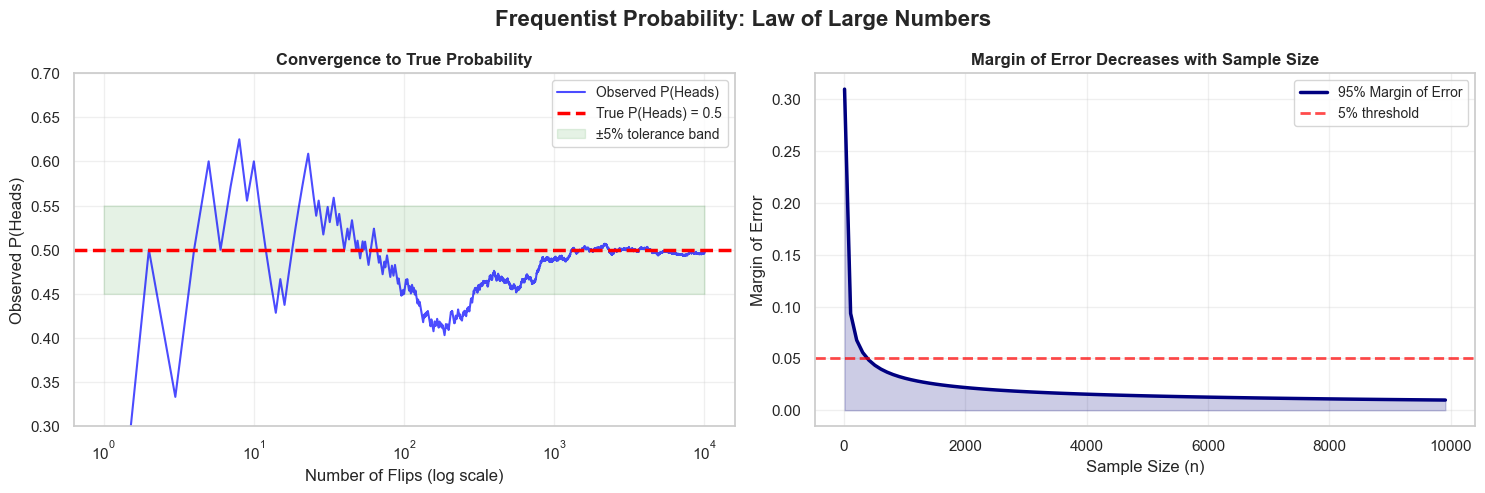


✓ Frequentist visualization saved!


In [7]:
# Visualization 3: Frequentist Convergence
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Frequentist Probability: Law of Large Numbers', fontsize=16, fontweight='bold')

# Plot 1: Convergence
ax = axes[0]
n_flips = 10000
flips = np.random.binomial(n=1, p=0.5, size=n_flips)
cumulative_heads = np.cumsum(flips)
flip_numbers = np.arange(1, n_flips + 1)
running_probability = cumulative_heads / flip_numbers

ax.plot(flip_numbers, running_probability, linewidth=1.5, alpha=0.7, color='blue', label='Observed P(Heads)')
ax.axhline(0.5, color='red', linestyle='--', linewidth=2.5, label='True P(Heads) = 0.5')
ax.fill_between(flip_numbers, 0.45, 0.55, alpha=0.1, color='green', label='±5% tolerance band')
ax.set_xscale('log')
ax.set_title('Convergence to True Probability', fontweight='bold')
ax.set_xlabel('Number of Flips (log scale)')
ax.set_ylabel('Observed P(Heads)')
ax.set_ylim([0.3, 0.7])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Standard Error vs Sample Size
ax = axes[1]
n_values = np.arange(10, 10000, 100)
std_errors = np.sqrt(0.5 * 0.5 / n_values)
z_95 = 1.96
margin_of_error = z_95 * std_errors

ax.plot(n_values, margin_of_error, linewidth=2.5, color='navy', label='95% Margin of Error')
ax.fill_between(n_values, margin_of_error, alpha=0.2, color='navy')
ax.axhline(0.05, color='red', linestyle='--', linewidth=2, alpha=0.7, label='5% threshold')
ax.set_title('Margin of Error Decreases with Sample Size', fontweight='bold')
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('Margin of Error')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/salmansakib/Documents/Projects/interview-Prep-Case-Study/Job Ready AI Bootcamp/week 3/Class 2 Project/lecture_3_frequentist.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Frequentist visualization saved!")

---

# SECTION E: TOPIC 4 - BAYESIAN PROBABILITY

## What is Bayesian Probability?

**Bayesian Probability** = Degree of belief that updates with evidence

### Core Idea
> "Probability represents your current belief. As you get new evidence, you update your belief."

### Bayes' Theorem (The Formula)
$$P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}$$

### Breaking Down the Formula

| Term | Name | Meaning |
|------|------|----------|
| **P(A\|B)** | **Posterior** | Your updated belief after seeing evidence B |
| **P(B\|A)** | **Likelihood** | How likely is the evidence given A is true? |
| **P(A)** | **Prior** | Your initial belief before any evidence |
| **P(B)** | **Evidence** | Total probability of observing B |

### Real-World Example: Medical Test

**Scenario**:
- A disease affects 1% of the population (rare!)
- A test is 99% accurate (seems good!)
- You test positive
- Question: Do you actually have the disease?

**Intuition**: "99% accurate test = I'm 99% likely to have it"  
**Reality**: "Only ~50% chance I actually have it!"

**Why?** False positives dominate because disease is rare!

### Calculation
```
Prior: P(Disease) = 1%
Likelihood: P(Positive|Disease) = 99%
False Positive Rate: P(Positive|No Disease) = 1%

1000 people:
  • 10 have disease (1%)
  • ~9.9 test positive (from diseased)
  • ~9.9 test positive (false positives!
  • Total positive: ~20
  • Of those, only ~9.9 actually have disease
  → P(Disease|Positive) = 9.9/20 ≈ 50%
```

### Key Insight
**The prior matters a lot!** If disease was 50% common, positive test → 98% likely to have it.

In [9]:
print("\n" + "="*70)
print("LECTURE 4: BAYESIAN PROBABILITY - BAYES' THEOREM")
print("="*70)

print("\n" + "-"*70)
print("Example: Medical Test Paradox")
print("-"*70)

# Given information
prior_disease = 0.01  # 1% of population has disease
sensitivity = 0.99    # P(Positive | Have disease) = 99%
specificity = 0.99    # P(Negative | No disease) = 99%

print(f"\nGiven Information:")
print(f"  • Disease prevalence: {prior_disease:.1%} (1 in 100 people)")
print(f"  • Test sensitivity: {sensitivity:.1%} (catches disease)")
print(f"  • Test specificity: {specificity:.1%} (avoids false alarm)")
print(f"\nScenario: You test POSITIVE")
print(f"\nQuestion: Do you actually have the disease?")

# Apply Bayes' Theorem
p_positive_given_disease = sensitivity
p_positive_given_no_disease = 1 - specificity  # False positive rate
p_disease = prior_disease
p_no_disease = 1 - prior_disease

# P(Positive) = P(Pos|Disease)*P(Disease) + P(Pos|No Disease)*P(No Disease)
p_positive = (p_positive_given_disease * p_disease) + (p_positive_given_no_disease * p_no_disease)

# P(Disease|Positive) = P(Positive|Disease) * P(Disease) / P(Positive)
posterior_disease = (p_positive_given_disease * p_disease) / p_positive

print(f"\n" + "="*70)
print("BAYES' THEOREM CALCULATION")
print("="*70)

print(f"\nStep 1: Calculate P(Positive)")
print(f"  P(+) = P(+|D)×P(D) + P(+|¬D)×P(¬D)")
print(f"       = {p_positive_given_disease:.2f}×{p_disease:.2f} + {p_positive_given_no_disease:.2f}×{p_no_disease:.2f}")
print(f"       = {p_positive_given_disease * p_disease:.4f} + {p_positive_given_no_disease * p_no_disease:.4f}")
print(f"       = {p_positive:.4f}")

print(f"\nStep 2: Apply Bayes' Theorem")
print(f"  P(D|+) = [P(+|D) × P(D)] / P(+)")
print(f"         = [{p_positive_given_disease:.2f} × {p_disease:.2f}] / {p_positive:.4f}")
print(f"         = {p_positive_given_disease * p_disease:.4f} / {p_positive:.4f}")
print(f"         = {posterior_disease:.4f}")

print(f"\n" + "="*70)
print(f"RESULT: P(Disease | Positive Test) = {posterior_disease:.1%}")
print("="*70)

print(f"\n🚨 COUNTERINTUITIVE RESULT!")
print(f"   Even with 99% accurate test, only {posterior_disease:.0%} chance you have disease!")

print(f"\n✓ Why? Because disease is RARE (1%), false positives dominate.")

# Show with actual numbers
print(f"\n" + "-"*70)
print("With 100,000 people:")
print("-"*70)

n_people = 100000
diseased = int(n_people * prior_disease)
healthy = n_people - diseased

true_positives = int(diseased * sensitivity)
false_positives = int(healthy * (1 - specificity))
total_positives = true_positives + false_positives

print(f"\n  • People with disease: {diseased:,}")
print(f"  • True positives (caught): {true_positives:,}")
print(f"  • People without disease: {healthy:,}")
print(f"  • False positives: {false_positives:,}")
print(f"  • Total positive tests: {total_positives:,}")
print(f"  • Of those, actually have disease: {true_positives:,}")
print(f"  → {true_positives/total_positives:.1%} of positive tests are truly diseased")


LECTURE 4: BAYESIAN PROBABILITY - BAYES' THEOREM

----------------------------------------------------------------------
Example: Medical Test Paradox
----------------------------------------------------------------------

Given Information:
  • Disease prevalence: 1.0% (1 in 100 people)
  • Test sensitivity: 99.0% (catches disease)
  • Test specificity: 99.0% (avoids false alarm)

Scenario: You test POSITIVE

Question: Do you actually have the disease?

BAYES' THEOREM CALCULATION

Step 1: Calculate P(Positive)
  P(+) = P(+|D)×P(D) + P(+|¬D)×P(¬D)
       = 0.99×0.01 + 0.01×0.99
       = 0.0099 + 0.0099
       = 0.0198

Step 2: Apply Bayes' Theorem
  P(D|+) = [P(+|D) × P(D)] / P(+)
         = [0.99 × 0.01] / 0.0198
         = 0.0099 / 0.0198
         = 0.5000

RESULT: P(Disease | Positive Test) = 50.0%

🚨 COUNTERINTUITIVE RESULT!
   Even with 99% accurate test, only 50% chance you have disease!

✓ Why? Because disease is RARE (1%), false positives dominate.

---------------------------

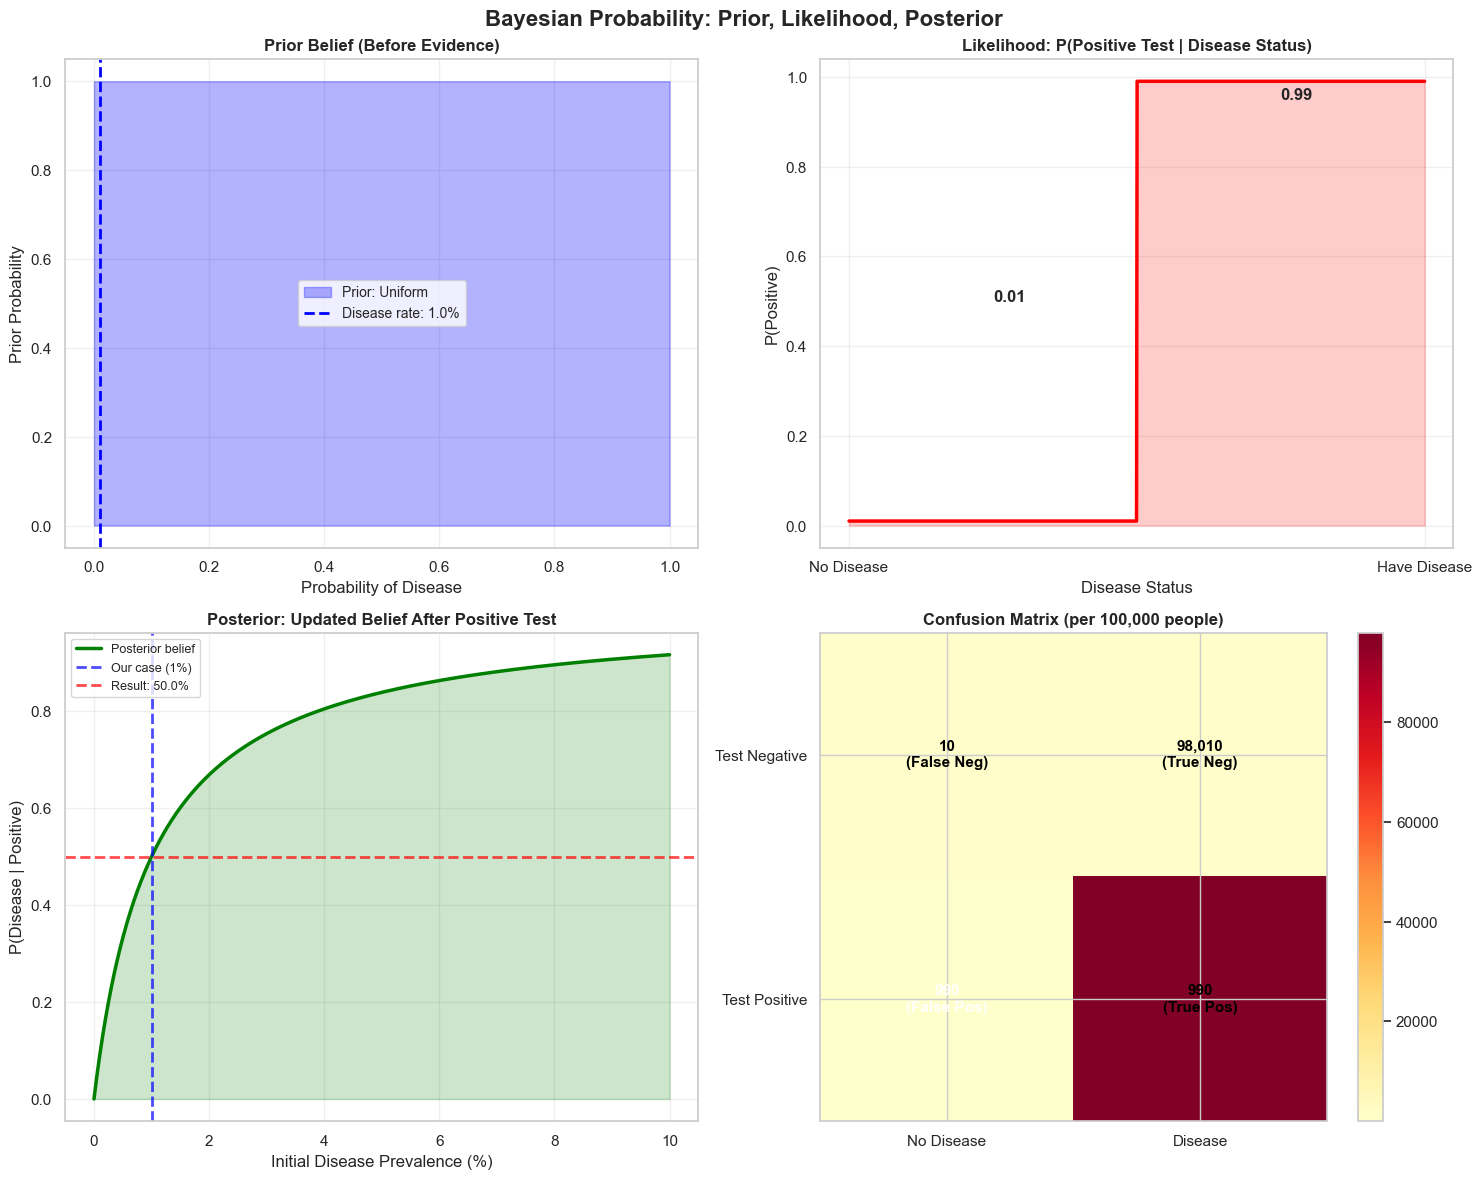


✓ Bayesian visualization saved!


In [10]:
# Visualization 4: Bayesian Reasoning
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Bayesian Probability: Prior, Likelihood, Posterior', fontsize=16, fontweight='bold')

# Plot 1: Prior distribution
ax = axes[0, 0]
x = np.linspace(0, 1, 1000)
prior_dist = np.ones_like(x)  # Uniform prior
ax.fill_between(x, prior_dist, alpha=0.3, color='blue', label='Prior: Uniform')
ax.axvline(prior_disease, color='blue', linestyle='--', linewidth=2, label=f'Disease rate: {prior_disease:.1%}')
ax.set_title('Prior Belief (Before Evidence)', fontweight='bold')
ax.set_xlabel('Probability of Disease')
ax.set_ylabel('Prior Probability')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Likelihood
ax = axes[0, 1]
# Show likelihood for positive test result
disease_space = np.linspace(0, 1, 1000)
likelihood_pos = np.where(disease_space > 0.5, sensitivity, 1 - specificity)
ax.plot(disease_space, likelihood_pos, linewidth=2.5, color='red')
ax.fill_between(disease_space, likelihood_pos, alpha=0.2, color='red')
ax.set_title('Likelihood: P(Positive Test | Disease Status)', fontweight='bold')
ax.set_xlabel('Disease Status')
ax.set_ylabel('P(Positive)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease', 'Have Disease'])
ax.text(0.25, 0.5, f'{1-specificity:.2f}', fontsize=12, fontweight='bold')
ax.text(0.75, 0.95, f'{sensitivity:.2f}', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: Posterior - updating belief
ax = axes[1, 0]
n_grid = 1000
disease_range = np.linspace(0, 0.1, n_grid)
posterior_vals = []

for prior in disease_range:
    p_pos = (sensitivity * prior) + ((1 - specificity) * (1 - prior))
    post = (sensitivity * prior) / p_pos
    posterior_vals.append(post)

ax.plot(disease_range * 100, posterior_vals, linewidth=2.5, color='green', label='Posterior belief')
ax.fill_between(disease_range * 100, posterior_vals, alpha=0.2, color='green')
ax.axvline(prior_disease * 100, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='Our case (1%)')
ax.axhline(posterior_disease, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Result: {posterior_disease:.1%}')
ax.set_title('Posterior: Updated Belief After Positive Test', fontweight='bold')
ax.set_xlabel('Initial Disease Prevalence (%)')
ax.set_ylabel('P(Disease | Positive)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Confusion matrix visualization
ax = axes[1, 1]
conf_matrix = np.array([
    [true_positives, 100000 - true_positives],
    [false_positives, 100000 - false_positives - diseased + true_positives]
])

im = ax.imshow([[true_positives, false_positives], 
                 [diseased - true_positives, healthy - false_positives]], 
                cmap='YlOrRd', aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Disease', 'Disease'])
ax.set_yticklabels(['Test Negative', 'Test Positive'])
ax.set_title('Confusion Matrix (per 100,000 people)', fontweight='bold')

# Add text
ax.text(0, 1, f'{false_positives:,}\n(False Pos)', ha='center', va='center', 
        color='white', fontweight='bold', fontsize=11)
ax.text(1, 1, f'{true_positives:,}\n(True Pos)', ha='center', va='center', 
        color='black', fontweight='bold', fontsize=11)
ax.text(0, 0, f'{diseased - true_positives:,}\n(False Neg)', ha='center', va='center', 
        color='black', fontweight='bold', fontsize=11)
ax.text(1, 0, f'{healthy - false_positives:,}\n(True Neg)', ha='center', va='center', 
        color='black', fontweight='bold', fontsize=11)

plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('/Users/salmansakib/Documents/Projects/interview-Prep-Case-Study/Job Ready AI Bootcamp/week 3/Class 2 Project/lecture_4_bayesian.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Bayesian visualization saved!")

---

# SECTION F: TOPIC 5 - CONFIDENCE SCORE SYSTEM FOR ML MODELS

## Building a Confidence Score System

Now we apply probability theory to **ML model confidence**.

### The Challenge
When your ML model makes a prediction, you want to know:
- "How confident is the model in this prediction?"
- "Should I trust this prediction?"
- "What's the confidence interval?"

### Solution: Two Approaches

#### 1. Frequentist Confidence
```
Confidence Score = Model Accuracy on Test Set

Example: Model was correct on 950 of 1000 test predictions
         → 95% confidence score
         → 95% CI: [93%, 97%]
```

#### 2. Bayesian Confidence  
```
Confidence = Expected Accuracy based on posterior distribution

Prior: Assume 50% accuracy initially
Data: Observe 950 correct, 50 incorrect
Posterior: Update belief using Beta distribution
Result: ~95% posterior accuracy
```

### Prediction-Level Confidence

For individual predictions, use the model's output probability:

**Example**: Spam detector outputs 0.92 (92% likely spam)
- Confidence = 92%
- Action: Auto-filter as spam

**Example**: Spam detector outputs 0.51 (51% likely spam)
- Confidence = 51% (very uncertain!)
- Action: Flag for human review

In [11]:
print("\n" + "="*70)
print("LECTURE 5: CONFIDENCE SCORES FOR ML MODELS")
print("="*70)

# Simulated email spam detection system
n_predictions = 1000
np.random.seed(42)

# True labels (30% spam, 70% not spam)
true_labels = np.random.binomial(n=1, p=0.3, size=n_predictions)

# Model predictions (raw scores 0-1)
model_scores = np.zeros(n_predictions)
for i in range(n_predictions):
    if true_labels[i] == 1:  # Spam
        model_scores[i] = np.random.normal(loc=0.7, scale=0.15)
    else:  # Not spam
        model_scores[i] = np.random.normal(loc=0.3, scale=0.15)

model_scores = np.clip(model_scores, 0, 1)

# Convert to binary predictions (threshold 0.5)
threshold = 0.5
predictions = (model_scores >= threshold).astype(int)

# Calculate metrics
accuracy = (predictions == true_labels).mean()
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print(f"\nSimulated Email Spam Detector System:")
print(f"-" * 70)
print(f"\nDataset: {n_predictions} emails")
print(f"  Spam emails: {true_labels.sum()} ({true_labels.mean():.1%})")
print(f"  Non-spam: {(1-true_labels).sum()} ({(1-true_labels).mean():.1%})")

print(f"\nModel Performance:")
print(f"  Accuracy:  {accuracy:.2%} (correct predictions)")
print(f"  Precision: {precision:.2%} (of predicted spam, how many are real?)")
print(f"  Recall:    {recall:.2%} (of real spam, how many did we catch?)")
print(f"  F1-Score:  {f1:.4f}")

print(f"\nPrediction Scores Statistics:")
print(f"  Mean score: {model_scores.mean():.3f}")
print(f"  Std Dev: {model_scores.std():.3f}")
print(f"  Range: [{model_scores.min():.3f}, {model_scores.max():.3f}]")


LECTURE 5: CONFIDENCE SCORES FOR ML MODELS

Simulated Email Spam Detector System:
----------------------------------------------------------------------

Dataset: 1000 emails
  Spam emails: 288 (28.8%)
  Non-spam: 712 (71.2%)

Model Performance:
  Accuracy:  87.50% (correct predictions)
  Precision: 73.49% (of predicted spam, how many are real?)
  Recall:    88.54% (of real spam, how many did we catch?)
  F1-Score:  0.8031

Prediction Scores Statistics:
  Mean score: 0.430
  Std Dev: 0.222
  Range: [0.000, 1.000]


In [12]:
print("\n" + "="*70)
print("FREQUENTIST CONFIDENCE SCORE")
print("="*70)

# Frequentist approach
overall_accuracy = (predictions == true_labels).mean()
se_accuracy = np.sqrt(overall_accuracy * (1 - overall_accuracy) / n_predictions)

# 95% Confidence Interval
z_95 = 1.96
ci_lower = overall_accuracy - z_95 * se_accuracy
ci_upper = overall_accuracy + z_95 * se_accuracy

confidence_frequentist = overall_accuracy * 100

print(f"\nMethod: Empirical Accuracy + Confidence Intervals")
print(f"\nCalculation:")
print(f"  1. Count correct predictions: {(predictions == true_labels).sum()}/{n_predictions}")
print(f"  2. Calculate accuracy: {overall_accuracy:.4f}")
print(f"  3. Standard error: √(p(1-p)/n) = {se_accuracy:.4f}")
print(f"  4. 95% CI = {overall_accuracy:.4f} ± 1.96 × {se_accuracy:.4f}")
print(f"           = {overall_accuracy:.4f} ± {z_95 * se_accuracy:.4f}")
print(f"           = [{ci_lower:.4f}, {ci_upper:.4f}]")

print(f"\n" + "="*70)
print(f"FREQUENTIST CONFIDENCE SCORE: {confidence_frequentist:.2f}%")
print(f"95% Confidence Interval: [{ci_lower:.2%}, {ci_upper:.2%}]")
print("="*70)

print(f"\nInterpretation:")
print(f"  'We are 95% confident that the true accuracy lies between")
print(f"   {ci_lower:.2%} and {ci_upper:.2%}.")
print(f"   If we deployed this model 100 times, ~95 times the accuracy")
print(f"   would fall within this range.'")


FREQUENTIST CONFIDENCE SCORE

Method: Empirical Accuracy + Confidence Intervals

Calculation:
  1. Count correct predictions: 875/1000
  2. Calculate accuracy: 0.8750
  3. Standard error: √(p(1-p)/n) = 0.0105
  4. 95% CI = 0.8750 ± 1.96 × 0.0105
           = 0.8750 ± 0.0205
           = [0.8545, 0.8955]

FREQUENTIST CONFIDENCE SCORE: 87.50%
95% Confidence Interval: [85.45%, 89.55%]

Interpretation:
  'We are 95% confident that the true accuracy lies between
   85.45% and 89.55%.
   If we deployed this model 100 times, ~95 times the accuracy
   would fall within this range.'


In [13]:
print("\n" + "="*70)
print("BAYESIAN CONFIDENCE SCORE")
print("="*70)

# Bayesian approach using Beta distribution
# Prior: Uninformative Beta(1, 1) = Uniform
alpha_prior = 1
beta_prior = 1

# Data
successes = (predictions == true_labels).sum()
failures = n_predictions - successes

# Posterior
alpha_post = alpha_prior + successes
beta_post = beta_prior + failures

# Posterior mean (expected accuracy)
posterior_mean = alpha_post / (alpha_post + beta_post)

# Posterior std dev
posterior_var = (alpha_post * beta_post) / ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1))
posterior_std = np.sqrt(posterior_var)

# Credible interval
credible_lower = beta_dist.ppf(0.025, alpha_post, beta_post)
credible_upper = beta_dist.ppf(0.975, alpha_post, beta_post)

confidence_bayesian = posterior_mean * 100

print(f"\nMethod: Beta Distribution + Bayesian Updating")
print(f"\nCalculation:")
print(f"  1. Prior belief: Beta({alpha_prior}, {beta_prior}) = Uniform(0,1)")
print(f"     (No initial belief, all accuracies equally likely)")
print(f"\n  2. Observed data:")
print(f"     Successes (correct): {successes}")
print(f"     Failures (incorrect): {failures}")
print(f"\n  3. Posterior distribution: Beta({alpha_post}, {beta_post})")
print(f"     α_post = 1 + {successes} = {alpha_post}")
print(f"     β_post = 1 + {failures} = {beta_post}")
print(f"\n  4. Posterior mean (expected accuracy):")
print(f"     E[accuracy] = {alpha_post}/{alpha_post + beta_post} = {posterior_mean:.4f}")
print(f"\n  5. 95% Credible Interval:")
print(f"     [{credible_lower:.4f}, {credible_upper:.4f}]")

print(f"\n" + "="*70)
print(f"BAYESIAN CONFIDENCE SCORE: {confidence_bayesian:.2f}%")
print(f"95% Credible Interval: [{credible_lower:.2%}, {credible_upper:.2%}]")
print("="*70)

print(f"\nInterpretation:")
print(f"  'Given our prior belief and observed data, we believe with")
print(f"   95% probability that the true accuracy is between")
print(f"   {credible_lower:.2%} and {credible_upper:.2%}.")
print(f"   Our best estimate: {posterior_mean:.2%} accuracy.'")


BAYESIAN CONFIDENCE SCORE

Method: Beta Distribution + Bayesian Updating

Calculation:
  1. Prior belief: Beta(1, 1) = Uniform(0,1)
     (No initial belief, all accuracies equally likely)

  2. Observed data:
     Successes (correct): 875
     Failures (incorrect): 125

  3. Posterior distribution: Beta(876, 126)
     α_post = 1 + 875 = 876
     β_post = 1 + 125 = 126

  4. Posterior mean (expected accuracy):
     E[accuracy] = 876/1002 = 0.8743

  5. 95% Credible Interval:
     [0.8530, 0.8941]

BAYESIAN CONFIDENCE SCORE: 87.43%
95% Credible Interval: [85.30%, 89.41%]

Interpretation:
  'Given our prior belief and observed data, we believe with
   95% probability that the true accuracy is between
   85.30% and 89.41%.
   Our best estimate: 87.43% accuracy.'


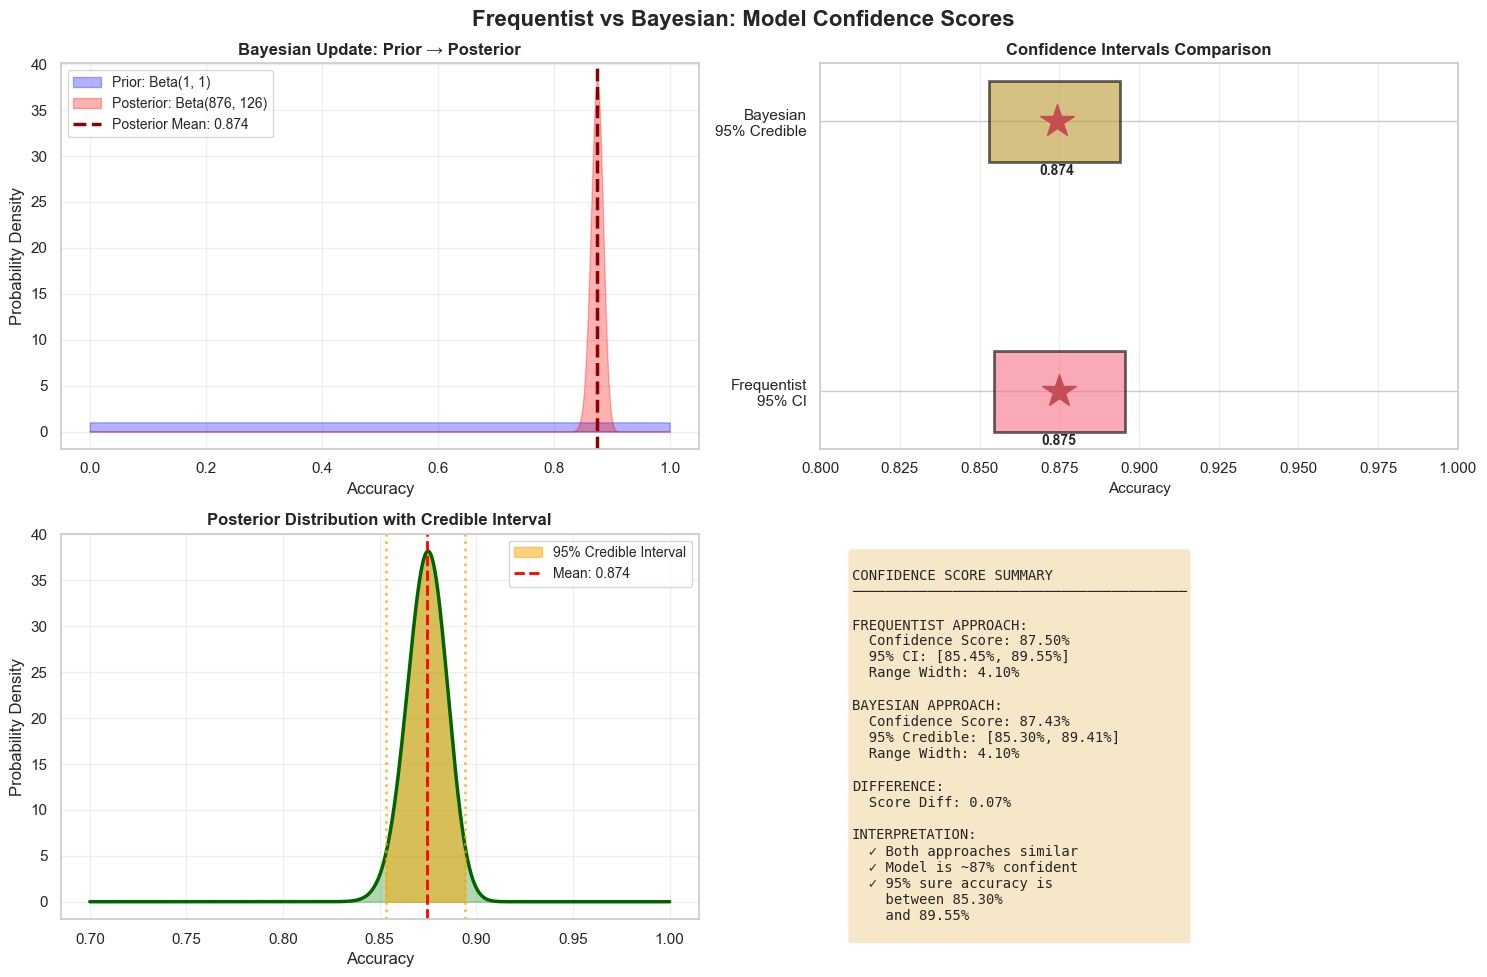


✓ Confidence score visualization saved!


In [14]:
# Visualization 5: Confidence Scores Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Frequentist vs Bayesian: Model Confidence Scores', fontsize=16, fontweight='bold')

# Plot 1: Prior vs Posterior
ax = axes[0, 0]
x = np.linspace(0, 1, 1000)
prior = beta_dist.pdf(x, alpha_prior, beta_prior)
posterior = beta_dist.pdf(x, alpha_post, beta_post)

ax.fill_between(x, prior, alpha=0.3, label=f'Prior: Beta({alpha_prior}, {beta_prior})', color='blue')
ax.fill_between(x, posterior, alpha=0.3, label=f'Posterior: Beta({alpha_post}, {beta_post})', color='red')
ax.axvline(posterior_mean, color='darkred', linestyle='--', linewidth=2.5, label=f'Posterior Mean: {posterior_mean:.3f}')
ax.set_title('Bayesian Update: Prior → Posterior', fontweight='bold')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Confidence Intervals Comparison
ax = axes[0, 1]
methods = ['Frequentist\n95% CI', 'Bayesian\n95% Credible']
centers = [overall_accuracy, posterior_mean]
lower_bounds = [ci_lower, credible_lower]
upper_bounds = [ci_upper, credible_upper]

for i, (method, center, lower, upper) in enumerate(zip(methods, centers, lower_bounds, upper_bounds)):
    width = upper - lower
    ax.barh(i, width, left=lower, height=0.3, alpha=0.6, edgecolor='black', linewidth=2)
    ax.plot([center], [i], 'r*', markersize=25, zorder=5)
    ax.text(center, i - 0.2, f'{center:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_yticks([0, 1])
ax.set_yticklabels(methods, fontsize=11)
ax.set_xlabel('Accuracy', fontsize=11)
ax.set_title('Confidence Intervals Comparison', fontweight='bold')
ax.set_xlim([0.8, 1.0])
ax.grid(True, alpha=0.3, axis='x')

# Plot 3: Posterior Distribution
ax = axes[1, 0]
x = np.linspace(0.7, 1.0, 1000)
y = beta_dist.pdf(x, alpha_post, beta_post)
ax.fill_between(x, y, alpha=0.3, color='green')
ax.plot(x, y, linewidth=2.5, color='darkgreen')

# Highlight credible interval
x_ci = x[(x >= credible_lower) & (x <= credible_upper)]
y_ci = beta_dist.pdf(x_ci, alpha_post, beta_post)
ax.fill_between(x_ci, y_ci, alpha=0.5, color='orange', label='95% Credible Interval')

ax.axvline(posterior_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {posterior_mean:.3f}')
ax.axvline(credible_lower, color='orange', linestyle=':', linewidth=2, alpha=0.7)
ax.axvline(credible_upper, color='orange', linestyle=':', linewidth=2, alpha=0.7)

ax.set_title('Posterior Distribution with Credible Interval', fontweight='bold')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Summary Table
ax = axes[1, 1]
ax.axis('off')

summary_text = f"""
CONFIDENCE SCORE SUMMARY
{'─'*40}

FREQUENTIST APPROACH:
  Confidence Score: {confidence_frequentist:.2f}%
  95% CI: [{ci_lower:.2%}, {ci_upper:.2%}]
  Range Width: {(ci_upper-ci_lower):.2%}

BAYESIAN APPROACH:
  Confidence Score: {confidence_bayesian:.2f}%
  95% Credible: [{credible_lower:.2%}, {credible_upper:.2%}]
  Range Width: {(credible_upper-credible_lower):.2%}

DIFFERENCE:
  Score Diff: {abs(confidence_frequentist-confidence_bayesian):.2f}%
  
INTERPRETATION:
  ✓ Both approaches similar
  ✓ Model is ~{(confidence_frequentist+confidence_bayesian)/2:.0f}% confident
  ✓ 95% sure accuracy is
    between {min(ci_lower, credible_lower):.2%}
    and {max(ci_upper, credible_upper):.2%}
"""

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('/Users/salmansakib/Documents/Projects/interview-Prep-Case-Study/Job Ready AI Bootcamp/week 3/Class 2 Project/lecture_5_confidence_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Confidence score visualization saved!")

---

# SECTION G: SUMMARY & KEY TAKEAWAYS

## What We Learned

### Topic 1: Normal Distribution
✅ Bell-shaped curve described by mean and std dev  
✅ 68-95-99.7 rule: Know where most data falls  
✅ Foundation for statistics and ML  

### Topic 2: Z-Scores
✅ Convert any value to standard scale  
✅ Find percentiles and detect outliers  
✅ Essential for ML preprocessing  

### Topic 3: Frequentist Probability
✅ Probability = long-run frequency  
✅ Confidence intervals quantify uncertainty  
✅ Works well with large samples  

### Topic 4: Bayesian Probability
✅ Probability = degree of belief  
✅ Update beliefs with evidence via Bayes' Theorem  
✅ Prior matters a lot!  

### Topic 5: Confidence Scores
✅ Quantify model certainty  
✅ Use both Frequentist and Bayesian approaches  
✅ Set thresholds for decision-making  

---

## Key Insights

| Insight | Why It Matters |
|---------|----------------|
| Normal distribution is everywhere | Understand defaults for ML models |
| Z-scores = standard scale | Different features comparable |
| Sample size matters | Larger n = narrower confidence intervals |
| Prior beliefs matter | Same evidence, different conclusions |
| Confidence ≠ Accuracy | Must validate calibration |

---

## Real-World Applications

### 1. Email Spam Detection
- Confidence >85%: Auto-filter
- Confidence 70-85%: Flag for review
- Confidence <70%: Allow (likely not spam)

### 2. Medical Diagnosis
- Use Bayesian approach
- Prior = disease prevalence
- Update with test results
- Get posterior probability

### 3. Fraud Detection
- Score each transaction
- Use confidence for routing
- High confidence = auto-block/approve
- Low confidence = manual review

### 4. Model Monitoring
- Track confidence over time
- Detect model drift
- Revert if confidence drops

---

## When to Use Each Approach

| Situation | Use Frequentist | Use Bayesian |
|-----------|-----------------|---------------|
| Large sample size | ✅ | ✓ |
| Small sample size | ⚠️ | ✅ |
| Have prior knowledge | ❌ | ✅ |
| No prior knowledge | ✅ | ✓ |
| Need confidence interval | ✅ | ✓ (credible) |
| Need belief update | ❌ | ✅ |
| Repeated experiments | ✅ | ✓ |

### Best Practice
**Use both!** They complement each other:
- Frequentist gives empirical grounding
- Bayesian incorporates domain expertise
- Together = comprehensive understanding

In [15]:
print("\n" + "="*70)
print("LECTURE SUMMARY: KEY TAKEAWAYS")
print("="*70)

summary = """

🎓 WHAT YOU LEARNED TODAY:

1. NORMAL DISTRIBUTION
   • Most common probability distribution
   • Defined by mean (μ) and std dev (σ)
   • 68-95-99.7 rule: Know where data falls
   → Use case: Detect outliers, test assumptions

2. Z-SCORES
   • Formula: Z = (X - μ) / σ
   • Standardize to mean=0, std=1
   • Find percentiles and unusual values
   → Use case: Feature scaling, outlier detection

3. FREQUENTIST PROBABILITY
   • Probability = long-run frequency
   • Confidence intervals quantify uncertainty
   • Larger samples = better estimates
   → Use case: Calculate model accuracy CI

4. BAYESIAN PROBABILITY
   • Probability = degree of belief
   • Update beliefs with evidence (Bayes' Theorem)
   • Prior belief strongly influences result
   → Use case: Medical diagnosis, model posteriors

5. CONFIDENCE SCORES
   • Quantify ML model certainty
   • Frequentist: Based on accuracy
   • Bayesian: Based on posterior distribution
   • Use for decision-making thresholds
   → Use case: Spam filtering, fraud detection

═══════════════════════════════════════════════════════════════════

🚀 ACTION ITEMS:

1. Review all 5 visualizations
2. Understand 68-95-99.7 rule deeply
3. Practice Z-score calculations
4. Memorize Bayes' Theorem
5. Think about when each approach applies
6. Calculate confidence for your own models

═══════════════════════════════════════════════════════════════════

💡 KEY INSIGHT:

"Probability is the language of uncertainty.
Master it, and you master AI."

═══════════════════════════════════════════════════════════════════

📚 NEXT STEPS:

• Read the CONCEPTS_GUIDE.md for deeper understanding
• Check FORMULA_REFERENCE.md for quick lookups
• Use confidence_calculator.py to run examples
• Apply to real data from your projects
• Track model confidence over time

"""

print(summary)


LECTURE SUMMARY: KEY TAKEAWAYS


🎓 WHAT YOU LEARNED TODAY:

1. NORMAL DISTRIBUTION
   • Most common probability distribution
   • Defined by mean (μ) and std dev (σ)
   • 68-95-99.7 rule: Know where data falls
   → Use case: Detect outliers, test assumptions

2. Z-SCORES
   • Formula: Z = (X - μ) / σ
   • Standardize to mean=0, std=1
   • Find percentiles and unusual values
   → Use case: Feature scaling, outlier detection

3. FREQUENTIST PROBABILITY
   • Probability = long-run frequency
   • Confidence intervals quantify uncertainty
   • Larger samples = better estimates
   → Use case: Calculate model accuracy CI

4. BAYESIAN PROBABILITY
   • Probability = degree of belief
   • Update beliefs with evidence (Bayes' Theorem)
   • Prior belief strongly influences result
   → Use case: Medical diagnosis, model posteriors

5. CONFIDENCE SCORES
   • Quantify ML model certainty
   • Frequentist: Based on accuracy
   • Bayesian: Based on posterior distribution
   • Use for decision-making th